# 03 · Énumération d'analogues et filtrage par docking
Troisième étape du pipeline : à partir de la morphine (récepteur µ, 5C1M) et de l'atropine (récepteur M2, 3UON), on construit des **bibliothèques d'analogues** en variant des groupes chimiques connus pour compter en relation structure-activité, on filtre, puis on **docke** chaque analogue avec le protocole du notebook 02 et on le compare à la molécule de référence.

**Ce n'est pas un modèle génératif profond.** C'est une énumération de bibliothèque virtuelle guidée par la chimie médicinale : on liste des substituants plausibles à des positions choisies et on génère toutes les combinaisons. L'avantage est qu'elle est rapide, entièrement reproductible et sans jeu de données d'entraînement. Un VAE sur SMILES ou REINVENT pourra venir ensuite (03b), en réutilisant le même filtrage par docking.

**Prérequis :** le re-docking du notebook 02 doit avoir été validé (RMSD < 2 Å) pour les deux cibles, sinon les scores d'ici ne sont pas interprétables. Durée attendue : 15 à 30 minutes dans Colab gratuit.

**Cellule 1 · Installation.** Installe les outils : RDKit (chimie), Vina (docking), Meeko (préparation des ligands), Biopython (lecture des PDB) et Open Babel (préparation du récepteur). Les outils de compilation requis par Vina sont installés d'abord. À lancer une seule fois par session.

In [ ]:
# 1. Installation (Colab)
import sys
if 'google.colab' in sys.modules:
    !apt-get -qq install -y openbabel swig libboost-all-dev > /dev/null
    !pip install -q rdkit meeko gemmi scipy biopython requests
    !pip install -q vina

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


**Cellule 2 · Imports et configuration.** Charge les bibliothèques et fixe le seed (42). Définit les deux cibles, la molécule de référence de chacune, et surtout les **bibliothèques virtuelles** : un gabarit SMILES et, pour chaque site de modification, la liste des substituants à tester. C'est la cellule à modifier pour changer les analogues générés ou leur nombre (`N_DOCK`).

In [ ]:
# 2. Imports et configuration
import shutil, subprocess, time, random, itertools
from pathlib import Path
import numpy as np, pandas as pd, requests
from Bio.PDB import PDBParser, PDBIO, Select
from rdkit import Chem, rdBase
from rdkit.Chem import AllChem, Draw, QED, Descriptors, Crippen, rdMolAlign, rdFingerprintGenerator, DataStructs
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from meeko import MoleculePreparation, PDBQTWriterLegacy, PDBQTMolecule, RDKitMolCreate
from vina import Vina

SEED = 42
N_DOCK = 10   # nombre d'analogues dockés par cible (augmente-le si tu as du temps)
WORK = Path('results_03'); WORK.mkdir(exist_ok=True)

TARGETS = {
    'mu_opioid':     {'pdb': '5C1M', 'chain': 'A', 'ligand_resname': None, 'exhaustiveness': 8,
                      'reference': ('morphine', 5288826)},
    'muscarinic_m2': {'pdb': '3UON', 'chain': 'A', 'ligand_resname': None, 'exhaustiveness': 8,
                      'reference': ('atropine', 'hyoscyamine')},
}

# Bibliothèques virtuelles : un gabarit SMILES + des listes de substituants (R-groupes) par site.
LIBRARIES = {
    'mu_opioid': {
        'template': '{NSUB}N1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5){OR})O[C@H]3[C@H](C=C4)O',
        'sites': {'NSUB': ['C', 'CC', 'C=CC', 'C%10CC%10C'],      # méthyle, éthyle, allyle, cyclopropylméthyle
                  'OR':   ['O', 'OC', 'OCC']},                    # OH, OMe, OEt en position 3
        'reference_groups': {'NSUB': 'C', 'OR': 'O'},
    },
    'muscarinic_m2': {
        'template': '{NSUB}N1[C@@H]2CC[C@H]1C[C@@H](C2)OC(=O)[C@H]({ALPHA}){RING}',
        'sites': {'NSUB':  ['C', 'CC', 'C(C)C'],                  # N-méthyle, éthyle, isopropyle
                  'ALPHA': ['CO', 'O', 'C', 'CC'],                # substituant du carbone alpha de l'ester
                  'RING':  ['c1ccccc1', 'c1ccc(F)cc1', 'c1ccc(Cl)cc1',
                            'c1ccc(OC)cc1', 'c1ccc(C)cc1', 'c1ccc(O)cc1']},  # cycle aromatique
        'reference_groups': {'NSUB': 'C', 'ALPHA': 'CO', 'RING': 'c1ccccc1'},
    },
}

def pubchem_smiles(ident):
    """SMILES isomérique depuis PubChem, par CID (int) ou par nom (str)."""
    kind = 'cid' if isinstance(ident, int) else 'name'
    url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/{kind}/{ident}/property/IsomericSMILES/TXT'
    r = requests.get(url, timeout=30); r.raise_for_status()
    return r.text.strip().splitlines()[0]

# Groupes HETATM ignorés lors de la détection automatique du ligand
EXCLUDE = {'HOH','NA','CL','K','MG','ZN','CA','MN','SO4','PO4','GOL','EDO','PEG','ACT','DMS','MES',
           'GDP','GTP','GNP','GSP','ANP','ATP','ADP','NAG','BMA','MAN','FUC'}
print('RDKit', rdBase.rdkitVersion, '| seed', SEED, '| analogues dockés par cible :', N_DOCK)

RDKit 2026.09.1 | seed 42 | analogues dockés par cible : 10


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Cellule 3a · Fonctions « protéines ».** Mêmes fonctions qu'au notebook 02 : téléchargement d'un PDB, détection du ligand co-cristallisé, séparation protéine / ligand, préparation du récepteur en PDBQT. Aucun affichage.

In [ ]:
# 3a. Fonctions : structures protéiques
def download_pdb(pdb_id):
    path = WORK / f'{pdb_id}.pdb'
    if not path.exists():
        r = requests.get(f'https://files.rcsb.org/download/{pdb_id}.pdb', timeout=60)
        r.raise_for_status()
        path.write_text(r.text)
    return path

def list_hetero(structure, chain_id):
    out = []
    for res in structure[0][chain_id]:
        name = res.get_resname().strip()
        if res.id[0].startswith('H_') and name not in EXCLUDE:
            n_heavy = sum(1 for a in res if (a.element or '').strip() != 'H')
            if n_heavy >= 8:
                out.append((name, res.id, n_heavy))
    return sorted(out, key=lambda x: -x[2])

class ProteinSelect(Select):
    def __init__(self, chain): self.chain = chain
    def accept_chain(self, chain): return chain.id == self.chain
    def accept_residue(self, res): return res.id[0] == ' '
    def accept_atom(self, atom): return atom.get_altloc() in (' ', 'A')

class LigandSelect(Select):
    def __init__(self, chain, rid): self.chain, self.rid = chain, rid
    def accept_chain(self, chain): return chain.id == self.chain
    def accept_residue(self, res): return res.id == self.rid
    def accept_atom(self, atom): return atom.get_altloc() in (' ', 'A')

def split_complex(pdb_path, chain_id, resname=None):
    s = PDBParser(QUIET=True).get_structure('x', str(pdb_path))
    if chain_id not in [c.id for c in s[0]]:
        raise RuntimeError(f"Chaîne {chain_id} absente de {pdb_path.name} : chaînes = {[c.id for c in s[0]]}")
    hets = list_hetero(s, chain_id)
    print('  Ligands candidats dans la chaîne', chain_id, '(nom, id, atomes lourds) :', hets[:6])
    if not hets:
        raise RuntimeError('Aucun ligand trouvé dans cette chaîne : change la chaîne dans TARGETS.')
    name, rid, n = next(h for h in hets if resname is None or h[0] == resname)
    io = PDBIO(); io.set_structure(s)
    stem = pdb_path.stem
    prot = WORK / f'{stem}_{chain_id}_protein.pdb'
    lig = WORK / f'{stem}_{name}_crystal.pdb'
    io.save(str(prot), ProteinSelect(chain_id))
    io.save(str(lig), LigandSelect(chain_id, rid))
    return prot, lig, name

def prepare_receptor(prot_pdb):
    out = prot_pdb.with_suffix('.pdbqt')
    cmd = ['obabel', str(prot_pdb), '-O', str(out), '-xr', '-p', '7.4']
    res = subprocess.run(cmd, capture_output=True, text=True)
    if not out.exists() or out.stat().st_size == 0:
        raise RuntimeError('Échec de la préparation du récepteur : ' + res.stderr[-500:])
    return out

**Cellule 3b · Fonctions « ligands et docking ».** Mêmes fonctions qu'au notebook 02 : reconstruction du ligand co-cristallisé, boîte de docking, conversion en PDBQT, lancement de Vina. Aucun affichage.

In [ ]:
# 3b. Fonctions : ligands, docking, RMSD
def crystal_ligand_mol(lig_pdb, resname):
    """Ligand expérimental avec ordres de liaison corrects (modèle : SDF idéal de la RCSB)."""
    raw = Chem.MolFromPDBFile(str(lig_pdb), sanitize=False, removeHs=False, proximityBonding=True)
    r = requests.get(f'https://files.rcsb.org/ligands/download/{resname}_ideal.sdf', timeout=60)
    r.raise_for_status()
    template = Chem.MolFromMolBlock(r.text, removeHs=True)
    mol = AllChem.AssignBondOrdersFromTemplate(template, raw)
    Chem.SanitizeMol(mol)
    return mol  # atomes lourds, coordonnées cristallographiques

def pocket_box(mol, padding=12.0, minimum=22.0):
    xyz = mol.GetConformer().GetPositions()
    center = xyz.mean(axis=0)
    size = np.maximum(xyz.max(axis=0) - xyz.min(axis=0) + padding, minimum)
    return center, size

def to_pdbqt(mol_h):
    setups = MoleculePreparation().prepare(mol_h)
    pdbqt, ok, err = PDBQTWriterLegacy.write_string(setups[0])
    if not ok:
        raise RuntimeError(err)
    return pdbqt

def run_vina(rec_pdbqt, lig_pdbqt, center, box, exhaustiveness, n_poses=10):
    t0 = time.time()
    box = np.minimum(box, 30)
    n_rec = sum(1 for l in open(rec_pdbqt) if l.startswith(('ATOM', 'HETATM')))
    print(f'  récepteur : {n_rec} atomes | centre {np.round(center, 1)} | boîte {np.round(box, 1)} Å')
    v = Vina(sf_name='vina', cpu=0, seed=SEED, verbosity=1)
    v.set_receptor(str(rec_pdbqt))
    v.set_ligand_from_string(lig_pdbqt)
    v.compute_vina_maps(center=[float(x) for x in center], box_size=[float(x) for x in box])
    v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)
    print(f'  terminé en {time.time()-t0:.0f}s | scores : {np.round(v.energies(n_poses=n_poses)[:, 0], 2)}')
    return v

def pose_rmsds(poses_pdbqt, ref_heavy):
    pm = PDBQTMolecule(poses_pdbqt, is_dlg=False, skip_typing=True)
    docked = Chem.RemoveAllHs(RDKitMolCreate.from_pdbqt_mol(pm)[0])
    ref_id = ref_heavy.GetConformer().GetId()
    return [rdMolAlign.CalcRMS(docked, ref_heavy, prbId=c.GetId(), refId=ref_id)
            for c in docked.GetConformers()]

## Préparation des cibles
Télécharge 5C1M et 3UON, isole la chaîne protéique, extrait le ligand co-cristallisé et définit la boîte de docking autour de lui, exactement comme au notebook 02. Vérifie à nouveau que le ligand retenu est le bon.

In [ ]:
prepared = {}
for key, cfg in TARGETS.items():
    print(f"=== {key} : {cfg['pdb']} chaîne {cfg['chain']}")
    pdb = download_pdb(cfg['pdb'])
    prot, lig, resname = split_complex(pdb, cfg['chain'], cfg['ligand_resname'])
    rec = prepare_receptor(prot)
    crystal = crystal_ligand_mol(lig, resname)
    center, box = pocket_box(crystal)
    prepared[key] = dict(receptor=rec, crystal=crystal, resname=resname, center=center, box=box)
    print(f"  Ligand retenu : {resname} ({crystal.GetNumAtoms()} atomes lourds)")
    print(f"  Centre : {np.round(center, 1)} | boîte : {np.round(box, 1)} Å")

=== mu_opioid : 5C1M chaîne A
  Ligands candidats dans la chaîne A (nom, id, atomes lourds) : [('VF1', ('H_VF1', 407, ' '), 32), ('CLR', ('H_CLR', 403, ' '), 28), ('P6G', ('H_P6G', 405, ' '), 19), ('OLC', ('H_OLC', 402, ' '), 18), ('OLC', ('H_OLC', 401, ' '), 16), ('P6G', ('H_P6G', 406, ' '), 13)]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[RDKit] WARNING:[22:12:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[RDKit] WARNING:[22:12:59] WARNING: More than one matching pattern found - picking one
[RDKit] WARNING:


  Ligand retenu : VF1 (32 atomes lourds)
  Centre : [  1.3  16.4 -59.1] | boîte : [22. 22. 22.] Å
=== muscarinic_m2 : 3UON chaîne A
  Ligands candidats dans la chaîne A (nom, id, atomes lourds) : [('QNB', ('H_QNB', 1162, ' '), 25), ('BGC', ('H_BGC', 1163, ' '), 12)]


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[RDKit] WARNING:[22:13:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[RDKit] WARNING:[22:13:00] WARNING: More than one matching pattern found - picking one
[RDKit] WARNING:


  Ligand retenu : QNB (25 atomes lourds)
  Centre : [ 7.8  0.3 -4. ] | boîte : [22. 22. 22.] Å


## Bibliothèques virtuelles d'analogues
**Morphine (µ)** : on varie le substituant de l'azote (méthyle, éthyle, allyle, cyclopropylméthyle) et l'oxygène en position 3 (OH, méthoxy, éthoxy). C'est la variation classique qui distingue morphine, codéine et dérivés N-allyle ou N-cyclopropylméthyle de la famille des antagonistes.

**Atropine (M2)** : on varie le substituant de l'azote du tropane, le substituant du carbone alpha de l'ester (hydroxyméthyle, hydroxyle, méthyle, éthyle) et le cycle aromatique (H, F, Cl, OMe, Me, OH).

**Ce que fait la cellule :** récupère les SMILES de référence sur PubChem, vérifie que le gabarit reproduit bien la référence (stéréochimie comprise), énumère toutes les combinaisons, retire les doublons et les motifs PAINS, puis calcule masse, logP, QED et similarité à la référence. Elle affiche six analogues. Certains analogues énumérés sont des médicaments connus.

=== mu_opioid | référence : morphine
  SMILES PubChem : CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O
  Gabarit cohérent avec PubChem (stéréochimie comprise) : OUI
  11 analogues retenus après filtre PAINS
=== muscarinic_m2 | référence : atropine
  SMILES PubChem : CN1[C@@H]2CC[C@H]1CC(C2)OC(=O)[C@H](CO)C3=CC=CC=C3
  Gabarit cohérent avec PubChem (stéréochimie comprise) : NON, à vérifier avant d'interpréter
  72 analogues retenus après filtre PAINS


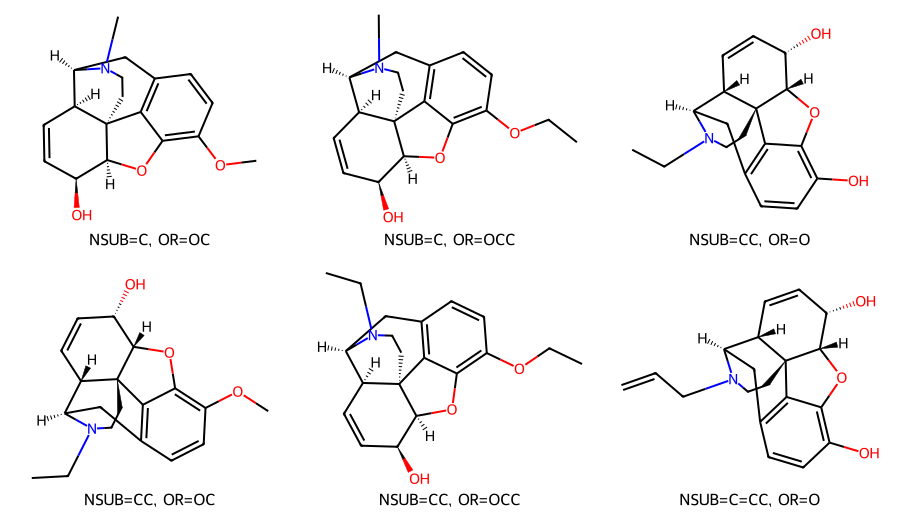

In [ ]:
# 4. Énumération des bibliothèques virtuelles
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fparams = FilterCatalogParams(); fparams.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains = FilterCatalog(fparams)

def canon(smi):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smi))

def enumerate_library(lib, ref_smiles):
    names = list(lib['sites'])
    ref_mol = Chem.MolFromSmiles(ref_smiles)
    ref_fp = fp_gen.GetFingerprint(ref_mol)
    seen, rows = {canon(ref_smiles)}, []
    for combo in itertools.product(*[lib['sites'][n] for n in names]):
        groups = dict(zip(names, combo))
        mol = Chem.MolFromSmiles(lib['template'].format(**groups))
        if mol is None:
            continue
        can = Chem.MolToSmiles(mol)
        if can in seen or pains.HasMatch(mol):
            continue
        seen.add(can)
        rows.append({'smiles': can, 'groups': ', '.join(f'{k}={v}' for k, v in groups.items()),
                     'MW': round(Descriptors.MolWt(mol), 1), 'logP': round(Crippen.MolLogP(mol), 2),
                     'QED': round(QED.qed(mol), 2),
                     'sim_ref': round(DataStructs.TanimotoSimilarity(fp_gen.GetFingerprint(mol), ref_fp), 2)})
    return rows

libraries = {}
for key, lib in LIBRARIES.items():
    ref_name, ident = TARGETS[key]['reference']
    ref_smiles = pubchem_smiles(ident)
    template_ref = lib['template'].format(**lib['reference_groups'])
    same = canon(template_ref) == canon(ref_smiles)
    print(f"=== {key} | référence : {ref_name}")
    print('  SMILES PubChem :', ref_smiles)
    print('  Gabarit cohérent avec PubChem (stéréochimie comprise) :', 'OUI' if same else 'NON, à vérifier avant d\'interpréter')
    rows = enumerate_library(lib, ref_smiles)
    libraries[key] = {'ref_name': ref_name, 'ref_smiles': ref_smiles, 'rows': rows}
    print(f'  {len(rows)} analogues retenus après filtre PAINS')

key0 = list(libraries)[0]
preview = [Chem.MolFromSmiles(r['smiles']) for r in libraries[key0]['rows'][:6]]
Draw.MolsToGridImage(preview, legends=[r['groups'] for r in libraries[key0]['rows'][:6]], subImgSize=(300, 260), molsPerRow=3)

## Docking des analogues
**Ce que fait la cellule :** pour chaque cible, dock d'abord la molécule de référence avec le même protocole (c'est la base de comparaison), puis un échantillon aléatoire de `N_DOCK` analogues (seed fixé). Chaque analogue passe par un conformère 3D RDKit (MMFF), est converti en PDBQT et docké. Les trois meilleures poses sont enregistrées. Une molécule dont la génération 3D ou le docking échoue est ignorée avec un message.

In [ ]:
# 5. Docking de la référence et des analogues
def dock_smiles(smiles, target_key, tag):
    p, cfg = prepared[target_key], TARGETS[target_key]
    mol_h = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if AllChem.EmbedMolecule(mol_h, randomSeed=SEED) != 0:
        raise RuntimeError('génération 3D impossible')
    AllChem.MMFFOptimizeMolecule(mol_h, maxIters=2000)
    v = run_vina(p['receptor'], to_pdbqt(mol_h), p['center'], p['box'], cfg['exhaustiveness'], n_poses=5)
    energies = v.energies(n_poses=5)[:, 0]
    v.write_poses(str(WORK / f'{tag}_poses.pdbqt'), n_poses=3, overwrite=True)
    return float(energies[0])

all_rows = []
for key in prepared:
    lib = libraries[key]
    sample = random.Random(SEED).sample(lib['rows'], min(N_DOCK, len(lib['rows'])))
    todo = [(f"{lib['ref_name']} (référence)", lib['ref_smiles'], '', {})]
    todo += [(f'{key}_analogue_{i+1}', r['smiles'], r['groups'], r) for i, r in enumerate(sample)]
    for name, smi, groups, r in todo:
        print(f'--- {key} | {name} {groups}')
        try:
            score = dock_smiles(smi, key, f"{key}_{name.split()[0]}")
        except Exception as e:
            print('  échec :', e); continue
        all_rows.append({'cible': key, 'molécule': name, 'modifications': groups, 'smiles': smi,
                         'score': round(score, 2), 'QED': r.get('QED') if r else None,
                         'sim_ref': r.get('sim_ref') if r else 1.0})
print('Terminé :', len(all_rows), 'dockings réussis')

--- mu_opioid | morphine (référence) 
  récepteur : 2820 atomes | centre [  1.3  16.4 -59.1] | boîte [22. 22. 22.] Å
  terminé en 12s | scores : [-8.29 -8.21 -8.02 -7.69 -7.53]
--- mu_opioid | mu_opioid_analogue_1 NSUB=C%10CC%10C, OR=OCC
  récepteur : 2820 atomes | centre [  1.3  16.4 -59.1] | boîte [22. 22. 22.] Å
  terminé en 20s | scores : [-8.73 -8.68 -8.67 -8.41 -8.29]
--- mu_opioid | mu_opioid_analogue_2 NSUB=C, OR=OCC
  récepteur : 2820 atomes | centre [  1.3  16.4 -59.1] | boîte [22. 22. 22.] Å
  terminé en 11s | scores : [-8.45 -8.22 -8.21 -8.2  -7.65]
--- mu_opioid | mu_opioid_analogue_3 NSUB=C, OR=OC
  récepteur : 2820 atomes | centre [  1.3  16.4 -59.1] | boîte [22. 22. 22.] Å
  terminé en 9s | scores : [-8.4  -8.32 -8.06 -8.05 -7.99]
--- mu_opioid | mu_opioid_analogue_4 NSUB=CC, OR=OCC
  récepteur : 2820 atomes | centre [  1.3  16.4 -59.1] | boîte [22. 22. 22.] Å
  terminé en 14s | scores : [-8.46 -8.31 -8.29 -8.18 -7.62]
--- mu_opioid | mu_opioid_analogue_5 NSUB=C%10CC%10

## Résultats
**Ce que fait la cellule :** assemble les scores, calcule l'écart `delta_vs_ref` par rapport à la référence de la même cible (négatif = score Vina meilleur que la référence), trie, affiche le tableau et les six meilleures structures par cible, puis enregistre le CSV et une archive `results_03.zip` que Colab télécharge.

,cible,molécule,modifications,score,QED,sim_ref,delta_vs_ref
0,mu_opioid,mu_opioid_analogue_6,"NSUB=C=CC, OR=OC",-8.86,0.86,0.58,-0.57
1,mu_opioid,mu_opioid_analogue_8,"NSUB=C%10CC%10C, OR=O",-8.79,0.82,0.71,-0.50
2,mu_opioid,mu_opioid_analogue_7,"NSUB=C=CC, OR=O",-8.77,0.82,0.72,-0.48
3,mu_opioid,mu_opioid_analogue_1,"NSUB=C%10CC%10C, OR=OCC",-8.73,0.85,0.55,-0.44
4,mu_opioid,mu_opioid_analogue_10,"NSUB=CC, OR=OC",-8.73,0.85,0.59,-0.44
5,mu_opioid,mu_opioid_analogue_5,"NSUB=C%10CC%10C, OR=OC",-8.64,0.86,0.57,-0.35
6,mu_opioid,mu_opioid_analogue_4,"NSUB=CC, OR=OCC",-8.46,0.87,0.57,-0.17
7,mu_opioid,mu_opioid_analogue_2,"NSUB=C, OR=OCC",-8.45,0.85,0.72,-0.16
8,mu_opioid,mu_opioid_analogue_3,"NSUB=C, OR=OC",-8.40,0.80,0.76,-0.11
9,mu_opioid,mu_opioid_analogue_9,"NSUB=CC, OR=O",-8.40,0.77,0.76,-0.11


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


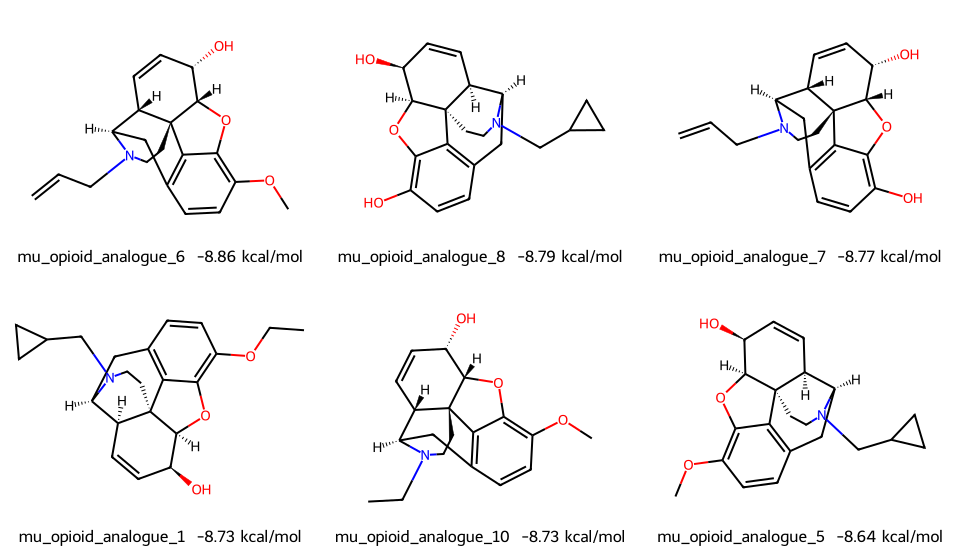

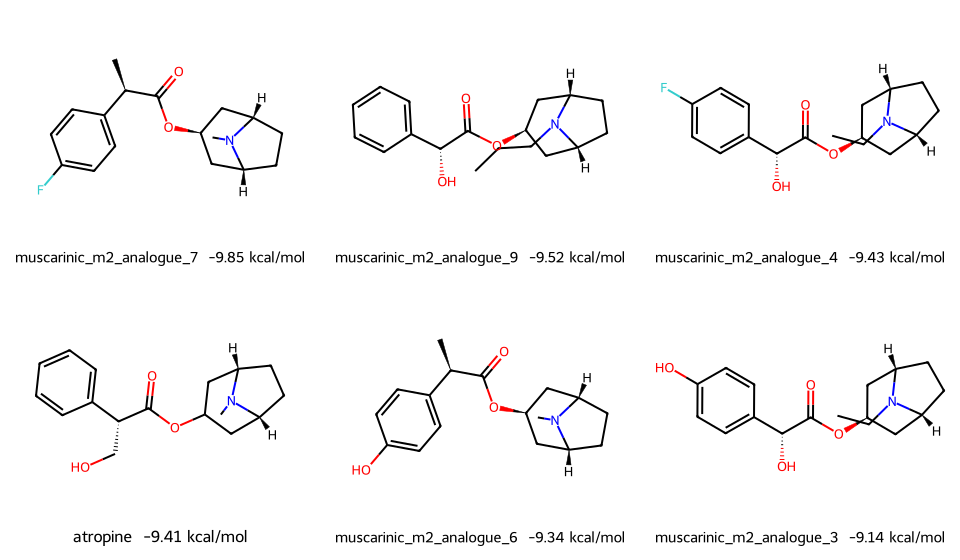

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 6. Résultats, images et sauvegarde
df = pd.DataFrame(all_rows)
ref_scores = df[df['molécule'].str.contains('référence')].set_index('cible')['score']
df['delta_vs_ref'] = (df['score'] - df['cible'].map(ref_scores)).round(2)
df = df.sort_values(['cible', 'score']).reset_index(drop=True)
display(df.drop(columns=['smiles']))

df.to_csv(WORK / 'analogues_docking.csv', index=False)
for key in df['cible'].unique():
    top = df[df['cible'] == key].head(6)
    img = Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in top['smiles']],
                               legends=[f"{m.split()[0]}  {sc} kcal/mol" for m, sc in zip(top['molécule'], top['score'])],
                               subImgSize=(320, 280), molsPerRow=3)
    display(img)
archive = shutil.make_archive('results_03', 'zip', WORK)
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(archive)

## Limites
- **Les scores Vina ne se comparent pas à des affinités mesurées.** Un `delta_vs_ref` faible est une hypothèse à tester, pas une prédiction d'activité. On ne compare jamais les scores entre les deux cibles.
- **Vina ne distingue pas agoniste et antagoniste.** Un analogue N-allyle ou N-cyclopropylméthyle de la morphine peut obtenir un bon score sans avoir l'effet pharmacologique attendu : l'efficacité dépend de la conformation induite du récepteur, que le docking sur récepteur rigide ne capture pas.
- La **stéréochimie** des analogues vient du gabarit (centres de la référence conservés), pas d'une énumération des stéréoisomères.
- Ligands dockés sous forme **neutre**, alors que les amines sont surtout protonées à pH physiologique.
- Aucune évaluation de **synthétisabilité**, de toxicité ni de propriétés ADME au-delà du QED et du filtre PAINS.
- Échantillon de `N_DOCK` analogues par cible, tirés au hasard : un classement ne couvre pas toute la bibliothèque.

## Étape suivante
Si les résultats sont cohérents, deux pistes : docker toute la bibliothèque (augmenter `N_DOCK`), ou ajouter un vrai modèle génératif (VAE sur SMILES) dont les molécules passeraient par le même filtrage.